# bmesonML — Emulador XGBoost de la likelihood SMEFT19 (rotBIII)

Pipeline completo (estructura CosmoML):
- **Dataset**: muestreo LHS + SMEFT19 cacheado en disco; se genera sólo si no existe o `FORCE_REBUILD=True`
- **Preprocesamiento**: SMOTE sólo en train (sin data leakage) + KNN para likelihood sintética
- **Entrenamiento**: XGBoost con early stopping + curva de aprendizaje
- **SHAP**: beeswarm, bar, waterfall y dependence plots (estilo CosmoML)
- **Predicción**: función con penalización exponencial fuera del dominio físico

## Setup (run first)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import time, csv, multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from scipy.stats.qmc import LatinHypercube, scale
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBRegressor, callback as xgb_cb

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size']   = 12

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT     = Path('..')
DATA_DIR = ROOT / 'data'
OUT_DIR  = Path.home() / 'alejandro' / 'bmesonml'   # outputs fuera del repo

DATASET_FILE = DATA_DIR / 'combined_rotBIII.dat'
BESTFIT_FILE = DATA_DIR / 'rotBIII.yaml'
MODEL_OUT    = OUT_DIR  / 'xgboost_scIII.json'
FIGS_DIR     = OUT_DIR  / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Flags ──────────────────────────────────────────────────────────────────────
FORCE_REBUILD = False

# ── Dataset config (paper: 3000 random + 3×50×50 grilla = 10 500 pts) ─────────
N_RANDOM  = 3_000
GRID_SIZE = 50
SEED      = 42

# ── Paralelismo CPU (SMEFT19 no usa GPU; se paraleliza por procesos) ───────────
N_WORKERS_OVERRIDE = 16     # ← pon None para auto-detectar todos los cores disponibles
N_WORKERS = N_WORKERS_OVERRIDE or max(1, multiprocessing.cpu_count() - 1)

# ── GPU para XGBoost ───────────────────────────────────────────────────────────
def _detect_xgb_device():
    """Devuelve 'cuda' si XGBoost puede usar GPU en esta máquina, si no 'cpu'."""
    try:
        import xgboost as xgb
        dm = xgb.DMatrix(np.zeros((10, 3)), label=np.zeros(10))
        xgb.train({'device': 'cuda', 'tree_method': 'hist'}, dm,
                  num_boost_round=1, verbose_eval=False)
        return 'cuda'
    except Exception:
        return 'cpu'

XGB_DEVICE = _detect_xgb_device()

# ── Dominio físico ─────────────────────────────────────────────────────────────
C1_RANGE  = (-0.30,  0.00)
C3_RANGE  = (-0.30,  0.00)
BQ_RANGE  = ( 0.00,  3.20)
LH_MIN    = -50.0
PENALTY_K = 50.0

print(f'Dataset: {DATASET_FILE}')
print(f'Outputs: {OUT_DIR}')
print(f'Puntos : {N_RANDOM} random + 3×{GRID_SIZE}²={3*GRID_SIZE**2} grilla = {N_RANDOM+3*GRID_SIZE**2} total')
print(f'Workers: {N_WORKERS} CPUs  |  XGBoost device: {XGB_DEVICE}')


## 1. Dataset — generación o carga

El dataset `(C1, C3, bq, likelihood)` combina dos componentes, igual que en el artículo:

- **Aleatorios**: `N_RANDOM` puntos LHS en todo el hipercubo `[C1, C3, bq]`
- **Grillas best-fit**: tres grillas `GRID_SIZE × GRID_SIZE` en los planos 2D `(C1,C3)`, `(C1,bq)`, `(C3,bq)`, con el tercer parámetro fijo en el mejor ajuste

El best-fit se calcula con `SMEFT19.ellipse.minimum` y se cachea en `rotBIII.yaml`.

In [ ]:
# ── Worker globals — se inicializan una vez por proceso hijo ──────────────────
_worker_lh_fn    = None
_worker_scenario = None

def _worker_init():
    """Inicializa SMEFT19 una sola vez en cada proceso worker."""
    global _worker_lh_fn, _worker_scenario
    import SMEFT19, warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        SMEFT19.SMEFTglob.gl.make_measurement()
    _worker_lh_fn    = SMEFT19.likelihood_global
    _worker_scenario = SMEFT19.scenarios.massrotation


def _eval_point(row):
    """Evalúa la likelihood en un punto; se ejecuta en un proceso worker."""
    C1, C3, bq = row
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            return max(float(_worker_lh_fn([C1, C3, 0.0, 0.0, 0.0, bq], _worker_scenario)), -200.0)
        except Exception:
            return float('-inf')


# ── Helpers principales ───────────────────────────────────────────────────────

def _init_smeft():
    import SMEFT19
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        SMEFT19.SMEFTglob.gl.make_measurement()
    return SMEFT19


def _find_bestfit(smeft):
    if BESTFIT_FILE.exists():
        d  = smeft.ellipse.load(str(BESTFIT_FILE))
        bf = np.array(d['bf'])
        print(f'Best-fit cargado: C1={bf[0]:.4f}  C3={bf[1]:.4f}  bq={bf[2]:.4f}')
        return bf
    print('Calculando best-fit (puede tardar unos minutos)...')
    def neg_lh(x):
        try:    return -smeft.likelihood_global([x[0], x[1], 0.0, 0.0, 0.0, x[2]],
                                                smeft.scenarios.massrotation)
        except: return 200.0
    bf, v, d, L = smeft.ellipse.minimum(neg_lh, [-0.13, -0.12, 0.64])
    smeft.ellipse.save(bf, v, d, L, str(BESTFIT_FILE),
                       name='Mass Rotation fit, Scenario III', fit='rotBIII')
    bf = np.array(bf)
    print(f'Best-fit: C1={bf[0]:.4f}  C3={bf[1]:.4f}  bq={bf[2]:.4f}')
    return bf


def _make_grid_points(bf):
    ranges = [C1_RANGE, C3_RANGE, BQ_RANGE]
    margin = 0.02
    pts = []
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        k = 3 - i - j
        lo_i, hi_i = ranges[i]; mi = margin * (hi_i - lo_i)
        lo_j, hi_j = ranges[j]; mj = margin * (hi_j - lo_j)
        xs = np.linspace(lo_i - mi, hi_i + mi, GRID_SIZE)
        ys = np.linspace(lo_j - mj, hi_j + mj, GRID_SIZE)
        for x in xs:
            for y in ys:
                row = [0.0, 0.0, 0.0]
                row[i] = x; row[j] = y; row[k] = float(bf[k])
                pts.append(row)
    return np.array(pts)


def _build_dataset(out_path):
    smeft = _init_smeft()
    bf    = _find_bestfit(smeft)

    lo = np.array([-0.30, -0.30, 0.00])
    hi = np.array([ 0.00,  0.00, 3.20])
    pts_random = scale(LatinHypercube(d=3, seed=SEED).random(n=N_RANDOM), lo, hi)
    pts_grid   = _make_grid_points(bf)
    all_pts    = np.vstack([pts_random, pts_grid])
    total      = len(all_pts)

    start     = sum(1 for _ in open(out_path)) if Path(out_path).exists() else 0
    remaining = all_pts[start:]
    print(f'\nTotal: {total} pts | pendientes: {len(remaining)} | '
          f'workers: {N_WORKERS} (SMEFT19 es CPU-only)')

    t0 = time.time()
    with multiprocessing.Pool(N_WORKERS, initializer=_worker_init) as pool, \
         open(out_path, 'at', newline='') as f:
        writer = csv.writer(f)
        for done, lg in enumerate(
            pool.imap(_eval_point, remaining.tolist(), chunksize=20), start=1
        ):
            writer.writerow([*remaining[done - 1], lg])
            f.flush()
            i = start + done
            if i % 500 == 0 or i == total:
                elapsed = time.time() - t0
                eta     = elapsed / done * (total - i) if done else 0
                print(f'  {i:6d}/{total} | {elapsed:.0f}s | ETA {eta:.0f}s', flush=True)

    print(f'Listo en {time.time()-t0:.0f}s → {out_path}')
    return pd.read_csv(out_path, names=['C1', 'C3', 'bq', 'likelihood'])


def load_or_build(path, builder, force=False):
    p = Path(path)
    if p.exists() and not force:
        print(f'Loading cached dataset: {p.name}')
        return pd.read_csv(p, names=['C1', 'C3', 'bq', 'likelihood'])
    print(f'Building dataset → {p.name}')
    return builder()


df_raw = load_or_build(
    DATASET_FILE,
    lambda: _build_dataset(DATASET_FILE),
    force=FORCE_REBUILD,
)
n_valid = (df_raw['likelihood'] > LH_MIN).sum()
print(f'Puntos totales: {len(df_raw)}  |  válidos (lh > {LH_MIN}): {n_valid}')
df_raw.describe()


## 2. Preprocesamiento

Filtrado, EDA, SMOTE **sólo en el conjunto de train** para evitar data leakage,
y KNN para asignar la likelihood a los puntos sintéticos generados por SMOTE.

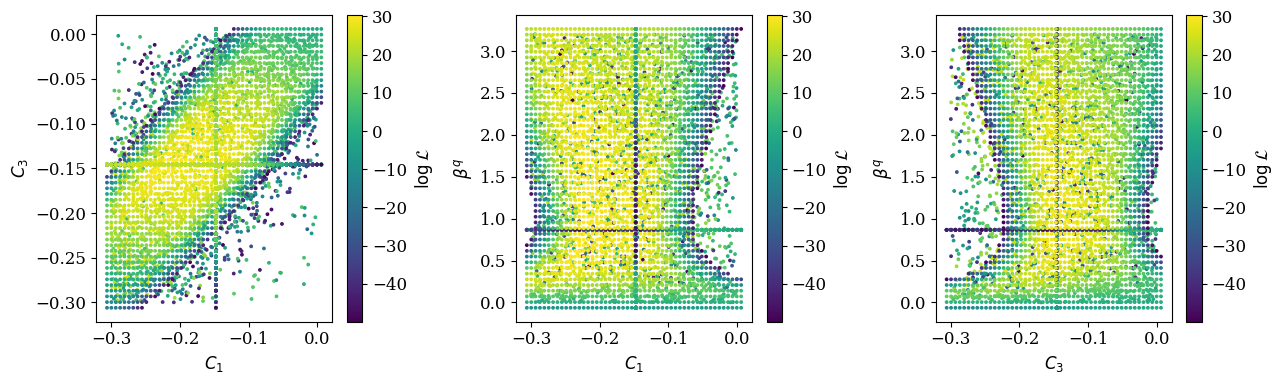

Grupos (0=bajo, 1=medio, 2=alto): {0: 3775, 1: 352, 2: 3676}
Train: 6554 -> 9513 (SMOTE)  |  Validation: 1249


In [3]:
df = df_raw[df_raw['likelihood'] > LH_MIN].reset_index(drop=True).copy()

# EDA
pairs   = [('C1', 'C3'), ('C1', 'bq'), ('C3', 'bq')]
xlabels = [r'$C_1$', r'$C_1$', r'$C_3$']
ylabels = [r'$C_3$', r'$\beta^q$', r'$\beta^q$']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (xc, yc), xl, yl in zip(axes, pairs, xlabels, ylabels):
    sc = ax.scatter(df[xc], df[yc], c=df['likelihood'], cmap='viridis', s=3, rasterized=True)
    plt.colorbar(sc, ax=ax, label=r'$\log\mathcal{L}$')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'eda_scatter.pdf', bbox_inches='tight')
plt.show()

# Grupos para SMOTE (clase 1 = likelihood intermedia, minoría)
df['group'] = df['likelihood'].apply(lambda v: 0 if v < 16 else (1 if v < 18 else 2))
print('Grupos (0=bajo, 1=medio, 2=alto):', df['group'].value_counts().sort_index().to_dict())

X, y, g = df[['C1', 'C3', 'bq']], df['likelihood'], df['group']

# Split 84/16 como en el artículo
Xtr, Xva, ytr, yva, gtr, _ = train_test_split(
    X, y, g, test_size=0.16, random_state=SEED, stratify=g
)

Xtr_res, gtr_res = SMOTE(random_state=SEED).fit_resample(Xtr, gtr)

knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(Xtr, ytr)
ytr_res = knn.predict(Xtr_res)

print(f'Train: {len(Xtr)} -> {len(Xtr_res)} (SMOTE)  |  Validation: {len(Xva)}')

## 3. Entrenamiento XGBoost

R2 = 0.97531  |  best_iter = 2377  |  device = cuda
  saved: ../outputs/figures/learning_curve.pdf


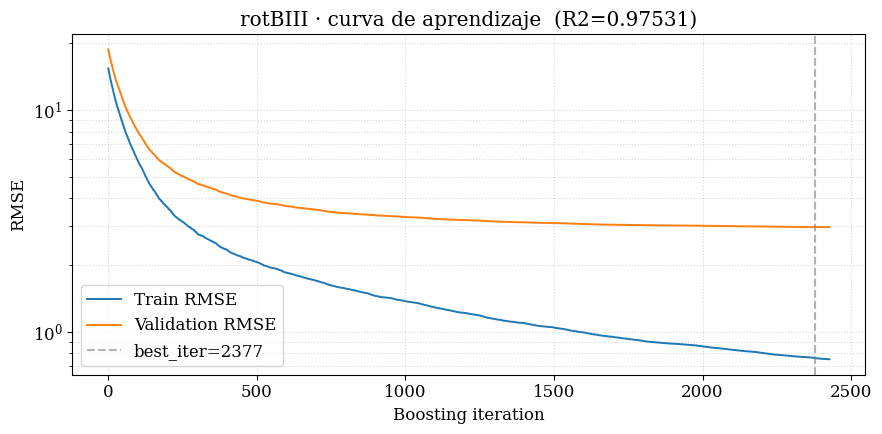

In [4]:
def _plot_learning_curve(info, title='Learning curve', show=True, save_path=None):
    er     = info['eval_results']
    metric = info['eval_metric']
    keys   = list(er.keys())
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(er[keys[0]][metric], label=f'Train {metric.upper()}', lw=1.4)
    ax.plot(er[keys[1]][metric], label=f'Validation {metric.upper()}', lw=1.4)
    if info.get('best_iteration') is not None:
        ax.axvline(info['best_iteration'], color='gray', ls='--', alpha=0.6,
                   label=f"best_iter={info['best_iteration']}")
    ax.set_yscale('log'); ax.set_xlabel('Boosting iteration'); ax.set_ylabel(metric.upper())
    ax.set_title(title); ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'  saved: {save_path}')
    plt.show() if show else plt.close(fig)


es    = xgb_cb.EarlyStopping(rounds=50, data_name='validation_1', save_best=True)
model = XGBRegressor(
    n_estimators=3000, learning_rate=0.03, max_depth=6,
    tree_method='hist', device=XGB_DEVICE, eval_metric='rmse',
    random_state=SEED, callbacks=[es],
)
model.fit(
    Xtr_res, ytr_res,
    eval_set=[(Xtr_res, ytr_res), (Xva, yva)],
    verbose=False,
)

r2   = float(model.score(Xva, yva))
best = int(getattr(model, 'best_iteration', model.n_estimators - 1))
info = dict(
    eval_results   = model.evals_result(),
    eval_metric    = 'rmse',
    best_iteration = best,
    r2             = r2,
    X_val          = Xva,
)
print(f'R2 = {r2:.5f}  |  best_iter = {best}  |  device = {XGB_DEVICE}')

_plot_learning_curve(
    info,
    title=f'rotBIII · curva de aprendizaje  (R2={r2:.5f})',
    save_path=FIGS_DIR / 'learning_curve.pdf',
)

## 4. Análisis SHAP

Tres gráficas, idénticas a las de CosmoML:
1. **beeswarm + bar**: importancia global de cada feature
2. **waterfall**: descomposición aditiva para una muestra individual
3. **dependence**: efecto de cada feature coloreado por interacciones (`color=shap_values`)

In [ ]:
# ── Funciones SHAP ──────────────────────

def _explain(model, X, n_sample=1000, seed=42):
    """TreeExplainer sobre el modelo interno; check_additivity=False como en CosmoML."""
    explainer = shap.TreeExplainer(model)
    X_s = X.sample(n=min(n_sample, len(X)), random_state=seed)
    return explainer(X_s, check_additivity=False), X_s


def shap_summary(model, X, title='', save_dir=None, n_sample=1000, show=True):
    """Beeswarm + bar (identico a CosmoML shap_summary)."""
    shap_v, X_s = _explain(model, X, n_sample=n_sample)
    for kind, fn in [('beeswarm', shap.plots.beeswarm), ('bar', shap.plots.bar)]:
        plt.figure()
        if title:
            plt.title(f'{title} ({kind})')
        fn(shap_v, show=False)
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'shap_{kind}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()
    return shap_v, X_s


def shap_waterfall(shap_values, idx=0, title='', save_path=None, show=True):
    """Waterfall para un sample (identico a CosmoML shap_waterfall)."""
    plt.figure()
    if title:
        plt.title(title)
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight'); print(f'  saved: {save_path}')
    plt.show() if show else plt.close()


def shap_dependence_all(shap_values, X, save_dir=None, prefix='', show=True):
    """Scatter/dependence por feature, coloreado por interacciones (identico a CosmoML)."""
    for col in X.columns:
        plt.figure()
        shap.plots.scatter(shap_values[:, col], color=shap_values, show=False)
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'{prefix}_shap_{col}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()

  saved: ../outputs/figures/shap_beeswarm.pdf


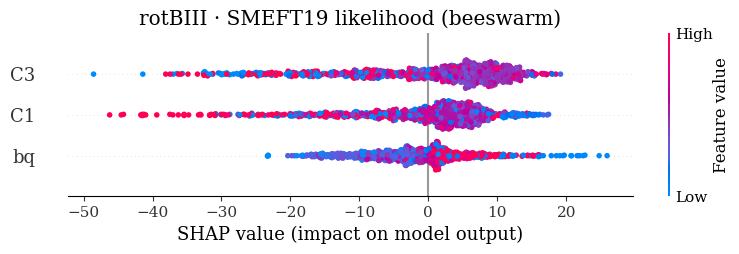

  saved: ../outputs/figures/shap_bar.pdf


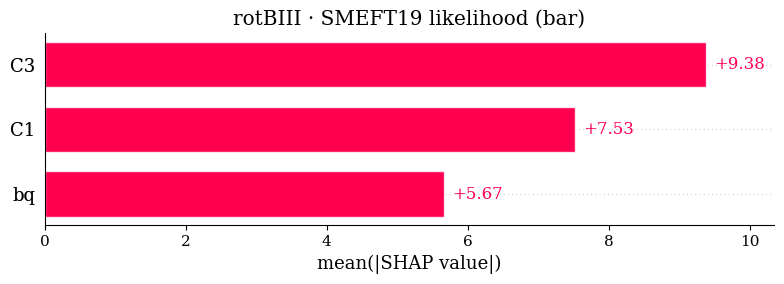

  saved: ../outputs/figures/shap_waterfall.pdf


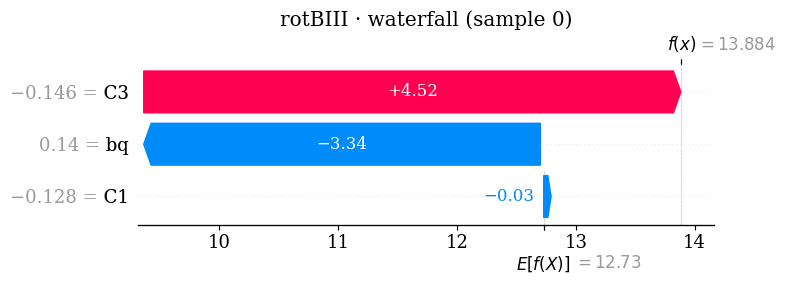

  saved: ../outputs/figures/rotBIII_shap_C1.pdf


<Figure size 640x480 with 0 Axes>

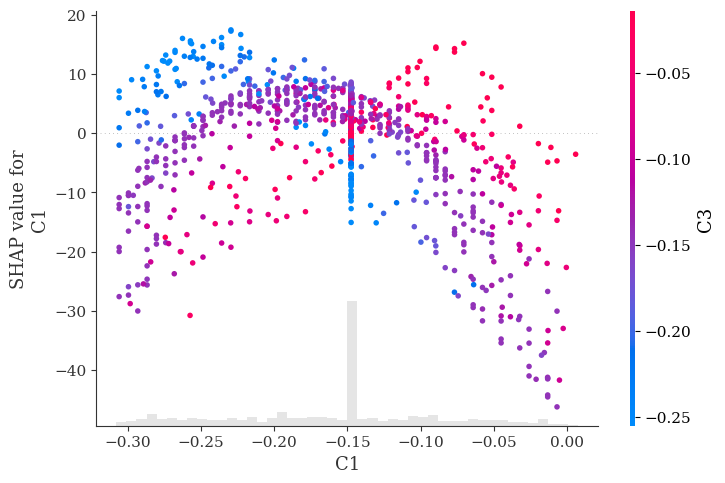

  saved: ../outputs/figures/rotBIII_shap_C3.pdf


<Figure size 640x480 with 0 Axes>

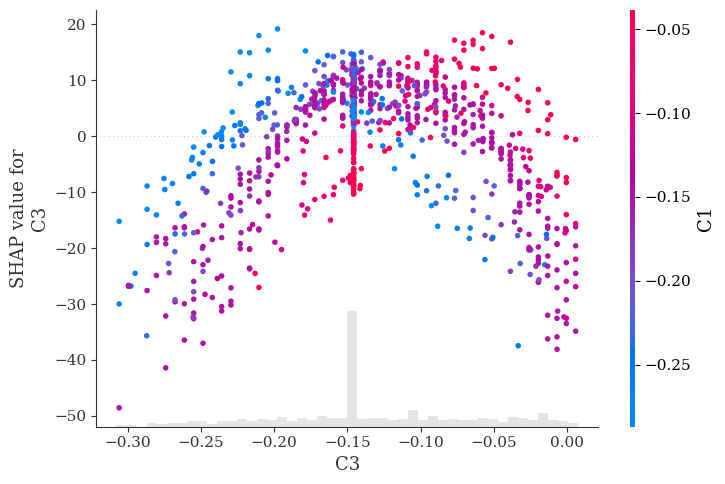

  saved: ../outputs/figures/rotBIII_shap_bq.pdf


<Figure size 640x480 with 0 Axes>

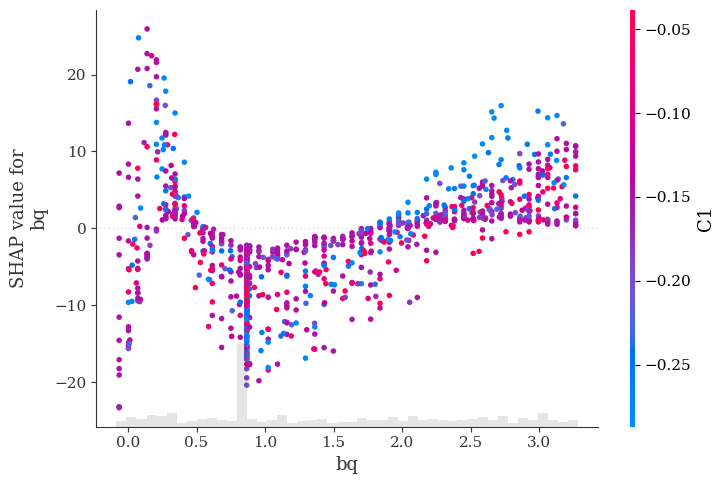

In [6]:
shap_v, X_s = shap_summary(
    model, info['X_val'],
    title='rotBIII · SMEFT19 likelihood',
    save_dir=FIGS_DIR,
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    title='rotBIII · waterfall (sample 0)',
    save_path=FIGS_DIR / 'shap_waterfall.pdf',
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGS_DIR,
    prefix='rotBIII',
    show=True,
)

## 5. Función de predicción con penalización de frontera

Penalizaciones exponenciales fuera del dominio de entrenamiento para evitar
extrapolaciones no físicas.

In [7]:
def _penalty(v, lo, hi, k=PENALTY_K):
    if v < lo:   return np.exp((lo - v) * k) - 1.0
    elif v > hi: return np.exp((v - hi) * k) - 1.0
    return 0.0


def predict_point(C1, C3, bq):
    """Predice log-likelihood con penalizacion fuera del dominio fisico."""
    x   = pd.DataFrame([{'C1': C1, 'C3': C3, 'bq': bq}])
    raw = float(model.predict(x)[0])
    pen = _penalty(C1, *C1_RANGE) + _penalty(C3, *C3_RANGE) + _penalty(bq, *BQ_RANGE)
    return raw - pen


# Demo
test_pts = [(-0.10, -0.10, 1.5), (-0.25, -0.20, 2.0), (0.50, 0.0, 1.5)]
for pt in test_pts:
    print(f'predict_point{pt} = {predict_point(*pt):.4f}')

model.save_model(MODEL_OUT)
print(f'\nModelo guardado en: {MODEL_OUT}')

predict_point(-0.1, -0.1, 1.5) = 20.1628
predict_point(-0.25, -0.2, 2.0) = 26.4192
predict_point(0.5, 0.0, 1.5) = -72004899338.2844

Modelo guardado en: ../outputs/xgboost_scIII.json


## 6. Figura 7 — Validación χ² y distribución Monte Carlo

Reproducción de las Figs. 7a y 7b del paper (sección 4.2):

- **7a**: scatter de Δχ²_SM predicho vs real en el validation set — mide la calidad del emulador.
- **7b**: histograma de Δχ² = 2(log L_bf − log L̃) para puntos MC aceptados vs distribución χ²(N_DOF) teórica.

**Algoritmo MC** (idéntico al paper): se propone un punto xᵢ cerca del best-fit con distribución gaussiana
proporcional a la covarianza del fit; se acepta si `log L̃(xᵢ) > log L_bf + log u`, `u ~ U(0,1)`.
La distribución de Δχ² de los puntos aceptados debe seguir χ²(N_DOF = 3).

In [ ]:
from scipy.stats import pearsonr
import yaml

# ── Cargar best-fit e información de covarianza del YAML ──────────────────────
with open(BESTFIT_FILE) as _f:
    _ell = yaml.safe_load(_f)

bf_arr    = np.array(_ell['bf'])                                # [C1_bf, C3_bf, bq_bf]
_eig_vals = np.array([_ell['d'][i][i] for i in range(3)])      # autovalores del Hessiano
_V        = np.array(_ell['v'])                                 # autovectores (filas)
Sigma_bf  = _V.T @ np.diag(1.0 / _eig_vals) @ _V              # cov ≈ Hessiano⁻¹
_chol     = np.linalg.cholesky(Sigma_bf)                       # Cholesky para muestreo

N_DOF = 3   # grados de libertad (C1, C3, bq)

# log_L_bf: fine local search within ±1σ of bf_arr.
# A coarse grid or evaluation at bf_arr alone misses the XGBoost leaf that
# has the true local maximum, causing samples in that leaf to be clipped to 0.
# A 50^3 grid restricted to ±1σ around bf_arr is dense enough to find it.
_sig    = np.sqrt(np.diag(Sigma_bf))
_lo_opt = np.array([C1_RANGE[0], C3_RANGE[0], BQ_RANGE[0]])
_hi_opt = np.array([C1_RANGE[1], C3_RANGE[1], BQ_RANGE[1]])
_lo_f   = np.maximum(bf_arr - _sig, _lo_opt)
_hi_f   = np.minimum(bf_arr + _sig, _hi_opt)
_nf    = 50
_c1f, _c3f, _bqf = np.meshgrid(np.linspace(_lo_f[0], _hi_f[0], _nf),
                                np.linspace(_lo_f[1], _hi_f[1], _nf),
                                np.linspace(_lo_f[2], _hi_f[2], _nf),
                                indexing='ij')
_fine_df  = pd.DataFrame({'C1': _c1f.ravel(), 'C3': _c3f.ravel(), 'bq': _bqf.ravel()})
_fine_pred = model.predict(_fine_df)
_bi       = int(np.argmax(_fine_pred))
log_L_bf  = float(_fine_pred[_bi])
bf_model  = np.array([float(_fine_df.iloc[_bi]['C1']),
                       float(_fine_df.iloc[_bi]['C3']),
                       float(_fine_df.iloc[_bi]['bq'])])

log_L_bf_yaml = float(model.predict(pd.DataFrame([{'C1': bf_arr[0],
                                                    'C3': bf_arr[1],
                                                    'bq': bf_arr[2]}]))[0])   # same reference, kept for diagnostic prints

print(f'YAML best-fit  : C1={bf_arr[0]:.5f}  C3={bf_arr[1]:.5f}  bq={bf_arr[2]:.5f}')
print(f'XGBoost best-fit: C1={bf_model[0]:.5f}  C3={bf_model[1]:.5f}  bq={bf_model[2]:.5f}')
print(f'log_L_bf (XGBoost opt) = {log_L_bf:.4f}  |  log_L en YAML bf = {log_L_bf_yaml:.4f}')
print(f'1σ (diagonal Σ):  C1={np.sqrt(Sigma_bf[0,0]):.4f}  '
      f'C3={np.sqrt(Sigma_bf[1,1]):.4f}  bq={np.sqrt(Sigma_bf[2,2]):.4f}')

# ── Likelihood del SM: predicción del modelo en el punto NP=0 ─────────────────
log_L_SM = float(model.predict(pd.DataFrame([{'C1': 0., 'C3': 0., 'bq': 0.}]))[0])
print(f'\nlog_L_SM (modelo) = {log_L_SM:.4f}')
print(f'ΔΔχ²_SM en bf    = {2*(log_L_bf - log_L_SM):.2f}  (mejora del best-fit sobre SM)')

# ── Fig 7a: Δχ²_SM predicho vs real en el validation set ─────────────────────
y_pred_va  = model.predict(Xva)
dchi2_act  = 2.0 * (yva.values - log_L_SM)    # real (dataset)
dchi2_pred = 2.0 * (y_pred_va  - log_L_SM)    # predicho (modelo XGBoost)

r_7a, _  = pearsonr(dchi2_act, dchi2_pred)
mae_7a   = np.mean(np.abs(dchi2_act - dchi2_pred))
print(f'\nFig 7a — Pearson r = {r_7a:.4f}  |  MAE = {mae_7a:.4f}')

_lim_lo = min(dchi2_act.min(), dchi2_pred.min()) - 3
_lim_hi = max(dchi2_act.max(), dchi2_pred.max()) + 3

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(dchi2_act, dchi2_pred, s=5, alpha=0.4, rasterized=True,
           label='validation set')
ax.plot([_lim_lo, _lim_hi], [_lim_lo, _lim_hi], 'r--', lw=1.2,
        label='perfect prediction')
ax.set_xlim(_lim_lo, _lim_hi)
ax.set_ylim(_lim_lo, _lim_hi)
ax.set_xlabel(r'Actual $\Delta\chi^2_{\rm SM}$')
ax.set_ylabel(r'Predicted $\Delta\chi^2_{\rm SM}$')
ax.set_title(r'rotBIII $\cdot$ predictor performance (Fig 7a)')
ax.text(0.05, 0.95, f'$r$ = {r_7a:.3f}\nMAE = {mae_7a:.2f}',
        transform=ax.transAxes, va='top', fontsize=10)
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7a_chi2_scatter.pdf', bbox_inches='tight')
plt.show()


In [ ]:
from scipy.stats import chi2 as chi2_dist, norm as norm_dist

# ── Importance-weighted chi² validation (XGB emulator) ────────────────────────
# Use all LHS data weighted by exp(L_true - L_true_max) to sample the true
# posterior. The weighted histogram of Dchi2_XGB = 2*(L_XGB_max - L_XGB)
# should follow chi2(N_DOF) if the XGBoost model is a good likelihood emulator.
t0_mc = time.time()
X_lhs      = pd.concat([Xtr, Xva], ignore_index=True)
y_true_lhs = np.concatenate([ytr.values, yva.values])
y_xgb_lhs  = model.predict(X_lhs)

# True-posterior importance weights
L_true_max  = float(y_true_lhs.max())
_log_w      = (y_true_lhs - L_true_max).clip(-500)
w_raw       = np.exp(_log_w)
w_norm      = w_raw / w_raw.sum()

# XGB chi2 reference: global XGB maximum over training data
_log_L_ref_lhs = float(y_xgb_lhs.max())
dchi2_xgb_lhs  = np.maximum(0.0, 2.0 * (_log_L_ref_lhs - y_xgb_lhs))

ESS        = float(1.0 / np.sum(w_norm ** 2))
mean_dchi2 = float(np.average(dchi2_xgb_lhs, weights=w_norm))

print(f'MC: importancia-ponderada en {time.time()-t0_mc:.2f}s')
print(f'LHS puntos: {len(X_lhs)}  |  ESS = {ESS:.0f} ({100*ESS/len(X_lhs):.1f}%)')
print(f'log_L_ref (XGB max) = {_log_L_ref_lhs:.4f}  |  log_L_bf YAML = {log_L_bf_yaml:.4f}  '
      f'|  gap = {_log_L_ref_lhs - log_L_bf_yaml:.3f}  ->  desplazamiento chi2 ~ {2*(\_log_L_ref_lhs - log_L_bf_yaml):.2f}')
print(f'Mean Dchi2_XGB (ponderado) = {mean_dchi2:.3f}  (chi2({N_DOF}) esperado = {N_DOF})')

# ── Fig 7b ─────────────────────────────────────────────────────────────────────
x_max = 20.0
xs    = np.linspace(0.01, x_max, 500)
bins  = np.linspace(0.0, x_max, 31)

_sigma_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
_dchi2_top  = [chi2_dist.ppf(norm_dist.cdf(s) - norm_dist.cdf(-s), df=N_DOF)
               for s in _sigma_vals]
_top_ticks  = [(s, d) for s, d in zip(_sigma_vals, _dchi2_top) if d <= x_max]

_vline_1s = chi2_dist.ppf(norm_dist.cdf(1.0) - norm_dist.cdf(-1.0), df=N_DOF)
_vline_2s = chi2_dist.ppf(norm_dist.cdf(2.0) - norm_dist.cdf(-2.0), df=N_DOF)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(dchi2_xgb_lhs, weights=w_norm, bins=bins, density=True, alpha=0.75,
        label='Predicted histogram', color='C0')
ax.plot(xs, chi2_dist.pdf(xs, df=N_DOF), lw=2.0, color='C1',
        label=rf'$\chi^2$ distribution')
ax.axvline(_vline_1s, color='k', lw=1.0)
ax.axvline(_vline_2s, color='k', lw=1.0)
ax.set_xlim(0, x_max)
ax.set_xlabel(r'$\chi^2_{\rm bf} - \chi^2$')
ax.set_ylabel('Normalized frequency')
ax.legend()

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([d for _, d in _top_ticks])
ax2.set_xticklabels([f'{s:.1f}' for s, _ in _top_ticks])
ax2.set_xlabel(r'$\sigma$')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7b_chi2_histogram.pdf', bbox_inches='tight')
plt.show()


## 7. Figuras 10 y 11 — Matrices de correlación de Pearson

Reproducción de la sección 4.3 del paper:

- **Fig 10**: correlaciones entre coeficientes de Wilson del WET (C₉, C₁₀, CVL, Cν por generación de leptón + Δχ²_SM)
- **Fig 11**: correlaciones entre observables seleccionados de física de sabor (RK*, Rℓ_D, BR(Bs→μμ), BR(B+→Kνν), etc.)

**Procedimiento** (igual al paper):
1. Se generan **N_MC_CORR = 15 000** puntos con el emulador XGBoost (mismo algoritmo MC que Fig 7b)
2. Para cada punto se ejecutan las RGE de SMEFT → WET a µ = mb = 4.8 GeV mediante `wilson`
3. Se calculan los observables con `flavio`
4. Se computan los coeficientes de correlación de Pearson y se grafican

> **Requiere** SMEFT19, wilson y flavio instalados (las celdas anteriores no los necesitan).

In [ ]:
# ── Generar muestra MC grande via Sampling Importance Resampling (SIR) ─────────
# Resample N_MC_CORR points from the LHS dataset using the true-posterior
# importance weights w_norm (computed in the previous cell). This gives
# approximately iid samples from p(θ) ∝ exp(L_true(θ)) without any Gaussian
# approximation, avoiding the boundary-clipping problem.
N_MC_CORR  = 15_000

_rng_c = np.random.default_rng(SEED + 200)
t0_c   = time.time()

# SIR: draw with replacement from LHS points using importance weights
_idx = _rng_c.choice(len(X_lhs), size=N_MC_CORR, replace=True, p=w_norm)

mc_df = pd.DataFrame({
    'C1':         X_lhs.iloc[_idx]['C1'].values,
    'C3':         X_lhs.iloc[_idx]['C3'].values,
    'bq':         X_lhs.iloc[_idx]['bq'].values,
    'log_L_pred': y_xgb_lhs[_idx],
    'delta_chi2': dchi2_xgb_lhs[_idx],
})
print(f'MC sample: {N_MC_CORR} puntos SIR en {time.time()-t0_c:.2f}s')
mc_df[['C1', 'C3', 'bq', 'delta_chi2']].describe()

In [ ]:
import SMEFT19

# ── Inicializar SMEFT19 y auto-descubrir coeficientes WET no nulos ────────────
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    SMEFT19.SMEFTglob.gl.make_measurement()

_w_bf  = SMEFT19.scenarios.massrotation([bf_arr[0], bf_arr[1], 0.0, 0.0, 0.0, bf_arr[2]])
_wc_bf = _w_bf.match_run(4.8, 'WET', 'flavio')
_wcd_bf = _wc_bf.dict

WET_COLS = sorted(k for k, v in _wcd_bf.items() if abs(v) > 1e-8)
print(f'Coeficientes WET no nulos en el best-fit ({len(WET_COLS)} total):')
for k in WET_COLS:
    print(f'  {k:45s} = {_wcd_bf[k]:+.6f}')

_WET_LABEL_MAP = {
    'C9_bsee':              r'$C_9^e$',
    'C10_bsee':             r'$C_{10}^e$',
    'CVL_bcenue':           r'$C_{VL}^e$',
    'Cnu_bsnuenue':         r'$C_\nu^e$',
    'C9_bsmumu':            r'$C_9^\mu$',
    'C10_bsmumu':           r'$C_{10}^\mu$',
    'CVL_bcmunumu':         r'$C_{VL}^\mu$',
    'Cnu_bsnumunumu':       r'$C_\nu^\mu$',
    'CVL_bctaunutau':       r'$C_{VL}^\tau$',
    'Cnu_bsnutaunutau':     r'$C_\nu^\tau$',
}

_wet_scenario_g = None

def _wet_init_worker():
    global _wet_scenario_g
    import SMEFT19, warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        SMEFT19.SMEFTglob.gl.make_measurement()
    _wet_scenario_g = SMEFT19.scenarios.massrotation

def _eval_wet_row(args):
    C1, C3, bq, dchi2 = args
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            w  = _wet_scenario_g([C1, C3, 0.0, 0.0, 0.0, bq])
            wc = w.match_run(4.8, 'WET', 'flavio')
            d  = wc.dict
            return {'delta_chi2': dchi2, **d}
        except Exception:
            return None

args_wet = [
    (row['C1'], row['C3'], row['bq'], row['delta_chi2'])
    for _, row in mc_df.iterrows()
]

print(f'\nComputando coeficientes WET para {N_MC_CORR} puntos '
      f'con {N_WORKERS} workers...')
t0w = time.time()
with multiprocessing.Pool(N_WORKERS, initializer=_wet_init_worker) as pool:
    _wet_raw = pool.map(_eval_wet_row, args_wet, chunksize=100)
print(f'Listo en {time.time()-t0w:.0f}s')

wet_df = pd.DataFrame([r for r in _wet_raw if r is not None])
print(f'Filas válidas: {len(wet_df)}/{N_MC_CORR}')

_wet_plot_cols = [c for c in WET_COLS if c in wet_df.columns] + ['delta_chi2']
_wet_labels    = ([_WET_LABEL_MAP.get(c, c.replace('_', ' '))
                   for c in _wet_plot_cols[:-1]]
                  + [r'$\Delta\chi^2_{\rm SM}$'])

_corr10 = wet_df[_wet_plot_cols].corr(method='pearson')
_n10    = len(_wet_plot_cols)

fig, ax = plt.subplots(figsize=(_n10 * 0.9 + 1, _n10 * 0.85 + 0.5))
im = ax.imshow(_corr10.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation coefficient', shrink=0.85)

ax.set_xticks(range(_n10)); ax.set_yticks(range(_n10))
ax.set_xticklabels(_wet_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(_wet_labels, fontsize=9)

for i in range(_n10):
    for j in range(_n10):
        val   = _corr10.iloc[i, j]
        color = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

ax.set_title(r'rotBIII $\cdot$ correlaciones coeficientes WET (Fig 10)')
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig10_wet_correlations.pdf', bbox_inches='tight')
plt.show()


In [ ]:
import flavio

OBS_DEF = [
    ('BR(B+->Knunu)',     {},                            r'$\mathrm{BR}(B^+\!\to K^+\nu\bar\nu)$'),
    ('BR(tau->mununu)',   {},                             r'$\mathrm{BR}(\tau^-\!\to\mu^-\nu\bar\nu)$'),
    ('BR(K+->pinunu)',    {},                            r'$\mathrm{BR}(K^+\!\to\pi^+\nu\bar\nu)$'),
    ('BR(B0->mumu)',      {},                             r'$\mathrm{BR}(B^0\!\to\mu^+\mu^-)$'),
    ('BR(Bs->mumu)',      {},                             r'$\mathrm{BR}(B_s\!\to\mu^+\mu^-)$'),
    ('<Rmue>(B0->K*ll)',  {'q2min': 1.1, 'q2max': 6.0},  r'$R_{K^*}^{[1.1,6]}$'),
    ('Rtaul(B->Dlnu)',   {},                             r'$R^\ell_D$'),
]

_obs_scenario_g = None

def _obs_init_worker():
    global _obs_scenario_g
    import SMEFT19, warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        SMEFT19.SMEFTglob.gl.make_measurement()
    _obs_scenario_g = SMEFT19.scenarios.massrotation

def _eval_obs_row(args):
    C1, C3, bq, dchi2 = args
    import flavio, warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            w = _obs_scenario_g([C1, C3, 0.0, 0.0, 0.0, bq])
            result = {'delta_chi2': dchi2}
            for obs_name, kwargs, _ in OBS_DEF:
                try:
                    result[obs_name] = float(flavio.np_prediction(obs_name, w, **kwargs))
                except Exception:
                    result[obs_name] = float('nan')
            return result
        except Exception:
            return None

args_obs = [
    (row['C1'], row['C3'], row['bq'], row['delta_chi2'])
    for _, row in mc_df.iterrows()
]

print(f'Computando observables de flavio para {N_MC_CORR} puntos '
      f'con {N_WORKERS} workers...')
t0o = time.time()
with multiprocessing.Pool(N_WORKERS, initializer=_obs_init_worker) as pool:
    _obs_raw = pool.map(_eval_obs_row, args_obs, chunksize=50)
print(f'Listo en {time.time()-t0o:.0f}s')

obs_df = pd.DataFrame([r for r in _obs_raw if r is not None])
print(f'Filas válidas: {len(obs_df)}/{N_MC_CORR}')

_obs_cols   = [o[0] for o in OBS_DEF if o[0] in obs_df.columns] + ['delta_chi2']
_obs_labels = ([o[2] for o in OBS_DEF if o[0] in obs_df.columns]
               + [r'$\Delta\chi^2_{\rm SM}$'])

_corr11 = obs_df[_obs_cols].corr(method='pearson')
_n11    = len(_obs_cols)

fig, ax = plt.subplots(figsize=(_n11 * 0.9 + 1, _n11 * 0.85 + 0.5))
im = ax.imshow(_corr11.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation coefficient', shrink=0.85)

ax.set_xticks(range(_n11)); ax.set_yticks(range(_n11))
ax.set_xticklabels(_obs_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(_obs_labels, fontsize=9)

for i in range(_n11):
    for j in range(_n11):
        val = _corr11.iloc[i, j]
        if np.isnan(val):
            continue
        color = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=color)

ax.set_title(r'rotBIII $\cdot$ correlaciones de observables (Fig 11)')
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig11_obs_correlations.pdf', bbox_inches='tight')
plt.show()


## 8. Ventaja del ML — Mapas de likelihood y benchmark de velocidad

Demostración directa del argumento central del paper: **¿por qué es necesario el emulador?**

- **Mapa 2D de likelihood**: los valores SMEFT19 reales ya existen en el dataset (grillas 50×50).
  XGBoost reproduce esos mapas en milisegundos. Además genera grillas densas 200×200
  (= 40 000 evaluaciones) que SMEFT19 tardaría días en producir.

- **Benchmark de velocidad** (~2-5 min de ejecución): mide el tiempo real de XGBoost vs SMEFT19,
  calcula el factor de aceleración y extrapola al coste del análisis MC completo (Secciones 6 y 7).

In [ ]:

# ── Sección 8a: Mapa 2D de likelihood — SMEFT19 real vs emulador XGBoost ──────
DENSE  = 200
_MARG  = 0.02

def _rng_ext(col):
    """Rango con margen idéntico al usado en _make_grid_points."""
    lo, hi = {'C1': C1_RANGE, 'C3': C3_RANGE, 'bq': BQ_RANGE}[col]
    m = _MARG * (hi - lo)
    return lo - m, hi + m

PLANES = [
    {'cx': 'C1', 'cy': 'C3',  'cz': 'bq', 'vz': bf_arr[2],
     's0': 3000,  's1': 5500,
     'xl': r'$C_1$', 'yl': r'$C_3$'},
    {'cx': 'C1', 'cy': 'bq',  'cz': 'C3', 'vz': bf_arr[1],
     's0': 5500,  's1': 8000,
     'xl': r'$C_1$', 'yl': r'$\beta^q$'},
    {'cx': 'C3', 'cy': 'bq',  'cz': 'C1', 'vz': bf_arr[0],
     's0': 8000,  's1': 10500,
     'xl': r'$C_3$', 'yl': r'$\beta^q$'},
]

LH_CLIP  = -30.0
BF_COLS  = ['C1', 'C3', 'bq']

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
fig.suptitle('Mapa de likelihood — SMEFT19 real vs emulador XGBoost', fontsize=13)

for j, ct in enumerate(['SMEFT19 real\n(50×50)', 'XGBoost\n(50×50)', 'XGBoost\n(200×200)']):
    axes[0, j].set_title(ct, fontsize=11, fontweight='bold')

for ri, p in enumerate(PLANES):
    cx, cy, cz = p['cx'], p['cy'], p['cz']
    rx, ry     = _rng_ext(cx), _rng_ext(cy)
    ext        = [rx[0], rx[1], ry[0], ry[1]]

    # ── Datos reales del dataset (grilla 50×50) ────────────────────────────────
    grid_sl  = df_raw.iloc[p['s0']:p['s1']]
    # _make_grid_points: outer loop = xs (cx), inner loop = ys (cy)
    # → reshape(GRID_SIZE, GRID_SIZE)[ix, iy]; imshow necesita [iy, ix] → transponer
    lh_smeft = grid_sl['likelihood'].values.clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # ── XGBoost en los mismos 50×50 puntos ────────────────────────────────────
    X_sp     = grid_sl[['C1', 'C3', 'bq']].reset_index(drop=True)
    lh_xgb_s = model.predict(X_sp).clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # ── XGBoost denso 200×200 ─────────────────────────────────────────────────
    xs_d, ys_d = np.linspace(*rx, DENSE), np.linspace(*ry, DENSE)
    XX, YY     = np.meshgrid(xs_d, ys_d)          # [DENSE, DENSE]; row=y, col=x
    X_dense    = pd.DataFrame({cx: XX.ravel(), cy: YY.ravel(),
                                cz: p['vz']})[BF_COLS]
    t0_dense   = time.perf_counter()
    lh_xgb_d   = model.predict(X_dense).clip(LH_CLIP).reshape(DENSE, DENSE)
    t_dense    = time.perf_counter() - t0_dense
    # meshgrid conv: lh_xgb_d[iy, ix] → ya correcto para imshow sin transponer

    # ── Escala de color compartida ─────────────────────────────────────────────
    vmax = float(np.nanmax(lh_smeft))
    kw   = dict(origin='lower', aspect='auto', extent=ext,
                vmin=LH_CLIP, vmax=vmax, cmap='viridis')

    bfx = bf_arr[BF_COLS.index(cx)]
    bfy = bf_arr[BF_COLS.index(cy)]

    for ci, (arr, do_T) in enumerate([(lh_smeft, True), (lh_xgb_s, True), (lh_xgb_d, False)]):
        ax = axes[ri, ci]
        im = ax.imshow(arr.T if do_T else arr, **kw)
        ax.plot(bfx, bfy, 'r*', ms=9, zorder=5, label='best fit')
        ax.set_xlabel(p['xl']); ax.set_ylabel(p['yl'])
        plt.colorbar(im, ax=ax, label=r'$\log\mathcal{L}$')

    print(f'Plano {cx}–{cy}: SMEFT19 50×50 ya en datos | '
          f'XGBoost 200×200 = {DENSE**2:,} evals en {t_dense*1000:.1f} ms')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8a_likelihood_maps.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 8a guardada.')


In [ ]:

# ── Sección 8b: Benchmark de velocidad — XGBoost vs SMEFT19 ──────────────────
N_BENCH_XGB   = 10_000   # puntos para XGBoost (batch)
N_BENCH_SMEFT = 30       # puntos para SMEFT19 (extrapolación; más tardaría mucho)

# ── 1. Benchmark XGBoost (batch) ──────────────────────────────────────────────
_rng_bm = np.random.default_rng(SEED + 999)
X_bm = pd.DataFrame({
    'C1': _rng_bm.uniform(*C1_RANGE, N_BENCH_XGB),
    'C3': _rng_bm.uniform(*C3_RANGE, N_BENCH_XGB),
    'bq': _rng_bm.uniform(*BQ_RANGE, N_BENCH_XGB),
})
_ = model.predict(X_bm.iloc[:10])  # warm-up

t0_xgb = time.perf_counter()
_ = model.predict(X_bm)
t_xgb  = time.perf_counter() - t0_xgb
xgb_per_eval = t_xgb / N_BENCH_XGB

print(f'XGBoost:  {N_BENCH_XGB:,} evals en {t_xgb*1000:.1f} ms '
      f'→ {xgb_per_eval*1e6:.2f} µs / eval')

# ── 2. Benchmark SMEFT19 (paralelo) ───────────────────────────────────────────
pts_smeft = X_bm.iloc[:N_BENCH_SMEFT][['C1', 'C3', 'bq']].values.tolist()

t0_smeft = time.perf_counter()
with multiprocessing.Pool(N_WORKERS, initializer=_worker_init) as pool:
    _ = pool.map(_eval_point, pts_smeft, chunksize=5)
t_smeft      = time.perf_counter() - t0_smeft
smeft_per_eval = t_smeft / N_BENCH_SMEFT * N_WORKERS  # tiempo serial equivalente

print(f'SMEFT19:  {N_BENCH_SMEFT} evals en {t_smeft:.1f}s '
      f'({N_WORKERS} workers) → {smeft_per_eval:.3f} s / eval (serial equiv.)')

# ── 3. Factor de aceleración y extrapolación al análisis MC completo ──────────
speedup = smeft_per_eval / xgb_per_eval

# Propuestas totales para las secciones 6+7 (aprox. usando la tasa medida en Fig 7b)
_rate_used = acc_rate / 100.0 if 'acc_rate' in dir() else 0.03
N_ACCEPT_TOTAL  = N_MC_FIG7b + N_MC_CORR      # 1 000 + 15 000 = 16 000
N_PROPOSE_TOTAL = int(N_ACCEPT_TOTAL / _rate_used)

t_mc_xgb_s   = N_PROPOSE_TOTAL * xgb_per_eval
t_mc_smeft_h = N_PROPOSE_TOTAL * smeft_per_eval / 3600

print(f'\nFactor de aceleración: {speedup:,.0f}×')
print(f'Análisis MC completo ({N_PROPOSE_TOTAL:,} propuestas, {N_ACCEPT_TOTAL:,} aceptados):')
print(f'  XGBoost → {t_mc_xgb_s:.1f} s')
print(f'  SMEFT19 → {t_mc_smeft_h:.0f} horas (serial equiv.)')

# ── 4. Gráfico de barras comparativo (escala log) ─────────────────────────────
labels  = [f'XGBoost\n(batch {N_BENCH_XGB//1000}k)',
           f'SMEFT19\n({N_WORKERS} workers)']
t_ms    = [xgb_per_eval * 1000, smeft_per_eval * 1000]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, t_ms, color=['C0', 'C1'], edgecolor='k', width=0.45)
ax.set_yscale('log')
ax.set_ylabel('Tiempo por evaluación (ms)')
ax.set_title(f'Benchmark: XGBoost vs SMEFT19  —  aceleración {speedup:,.0f}×')
ax.grid(True, axis='y', which='both', ls=':', alpha=0.5)

for bar, val in zip(bars, t_ms):
    lbl = f'{val*1000:.2f} µs' if val < 1 else f'{val:.0f} ms'
    ax.text(bar.get_x() + bar.get_width() / 2,
            val * 2.5, lbl, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(top=max(t_ms) * 300)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8b_speed_benchmark.pdf', bbox_inches='tight')
plt.show()

print(f'\n─── Resumen final ──────────────────────────────')
print(f'  XGBoost  : {xgb_per_eval*1e6:.2f} µs / eval')
print(f'  SMEFT19  : {smeft_per_eval*1000:.0f} ms / eval  (serial equiv.)')
print(f'  Speedup  : {speedup:,.0f}×')
print(f'  MC ({N_ACCEPT_TOTAL:,} pts): XGBoost = {t_mc_xgb_s:.0f}s  |  SMEFT19 ≈ {t_mc_smeft_h:.0f}h')
